# Loan Approval Prediction

Binary classification project predicting whether a loan application should be **approved (1)**
or **rejected (0)**, based on applicant demographics, income, employment, and credit-history
features.

**Dataset:** [Loan Approval Classification (Kaggle)](https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data) — 45,000 records, 14 columns, no missing values.

**Pipeline:** EDA → Outlier handling → Encoding/Scaling → Feature selection → Model training
(Logistic Regression, Random Forest, Neural Network) → Evaluation & comparison.

> Place the dataset at `data/loan_data.csv` before running (see `README.md`).


## 1. Setup and Data Loading

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)
import joblib

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

In [2]:
DATA_PATH = "data/loan_data.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found at '{DATA_PATH}'.\n"
        "Download it from Kaggle (see README.md) and place the CSV at that path."
    )

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (45000, 14)


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


## 2. Exploratory Data Analysis

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  45000 non-n

In [4]:
df.describe(include='all')

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
count,45000.000000,45000,45000,4.500000e+04,45000.000000,45000,45000.000000,45000,45000.000000,45000.000000,45000.000000,45000.000000,45000,45000.000000
unique,NaN,2,5,NaN,NaN,4,NaN,6,NaN,NaN,NaN,NaN,2,NaN
top,NaN,male,Bachelor,NaN,NaN,RENT,NaN,EDUCATION,NaN,NaN,NaN,NaN,Yes,NaN
freq,NaN,24841,13399,NaN,NaN,23443,NaN,9153,NaN,NaN,NaN,NaN,22858,NaN
mean,27.764178,NaN,NaN,8.031905e+04,5.410333,NaN,9583.157556,NaN,11.006606,0.139725,5.867489,632.608756,NaN,0.222222
std,6.045108,NaN,NaN,8.042250e+04,6.063532,NaN,6314.886691,NaN,2.978808,0.087212,3.879702,50.435865,NaN,0.415744
min,20.000000,NaN,NaN,8.000000e+03,0.000000,NaN,500.000000,NaN,5.420000,0.000000,2.000000,390.000000,NaN,0.000000
25%,24.000000,NaN,NaN,4.720400e+04,1.000000,NaN,5000.000000,NaN,8.590000,0.070000,3.000000,601.000000,NaN,0.000000
50%,26.000000,NaN,NaN,6.704800e+04,4.000000,NaN,8000.000000,NaN,11.010000,0.120000,4.000000,640.000000,NaN,0.000000
75%,30.000000,NaN,NaN,9.578925e+04,8.000000,NaN,12237.250000,NaN,12.990000,0.190000,8.000000,670.000000,NaN,0.000000


In [5]:
print("Missing values per column:\n")
df.isna().sum()

Missing values per column:



person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [6]:
categorical_cols = [
    'person_gender',
    'person_education',
    'person_home_ownership',
    'loan_intent',
    'previous_loan_defaults_on_file'
]

for col in categorical_cols:
    print(f"\nFrequency table for {col}")
    print(df[col].value_counts())


Frequency table for person_gender
person_gender
male      24841
female    20159
Name: count, dtype: int64

Frequency table for person_education
person_education
Bachelor       13399
Associate      12028
High School    11972
Master          6980
Doctorate        621
Name: count, dtype: int64

Frequency table for person_home_ownership
person_home_ownership
RENT        23443
MORTGAGE    18489
OWN          2951
OTHER         117
Name: count, dtype: int64

Frequency table for loan_intent
loan_intent
EDUCATION            9153
MEDICAL              8548
VENTURE              7819
PERSONAL             7552
DEBTCONSOLIDATION    7145
HOMEIMPROVEMENT      4783
Name: count, dtype: int64

Frequency table for previous_loan_defaults_on_file
previous_loan_defaults_on_file
Yes    22858
No     22142
Name: count, dtype: int64


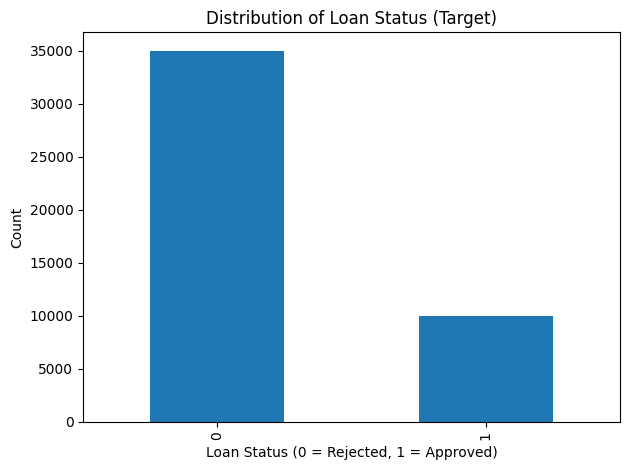

In [7]:
plt.figure()
df['loan_status'].value_counts().plot(kind='bar')
plt.xlabel("Loan Status (0 = Rejected, 1 = Approved)")
plt.ylabel("Count")
plt.title("Distribution of Loan Status (Target)")
plt.tight_layout()
plt.savefig("results/target_distribution.png")
plt.show()

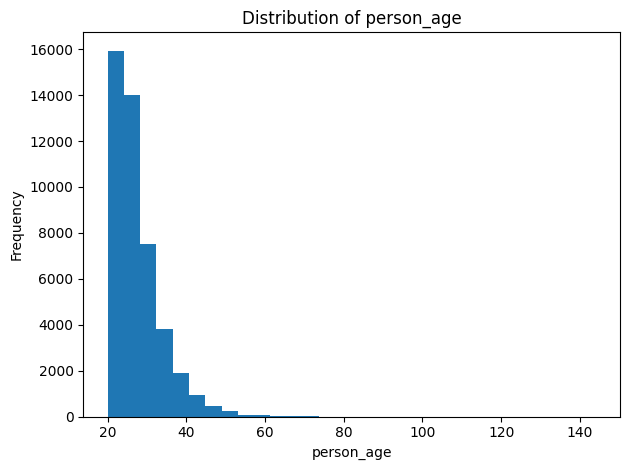

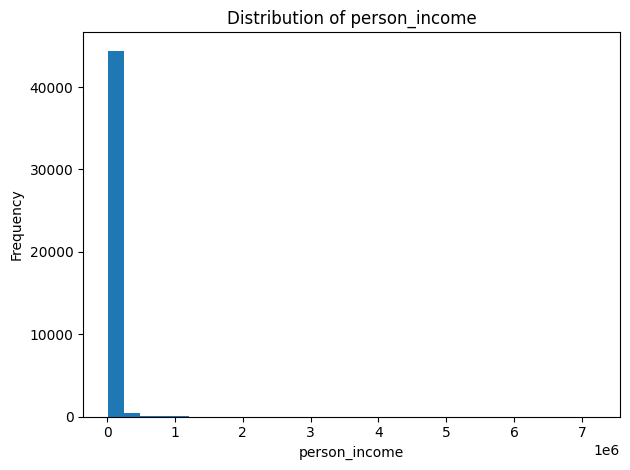

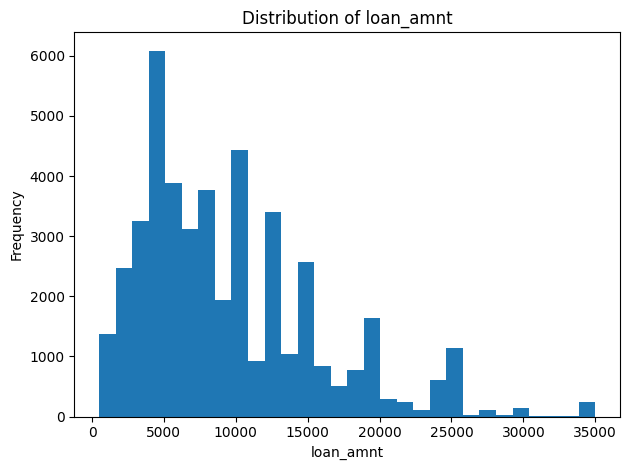

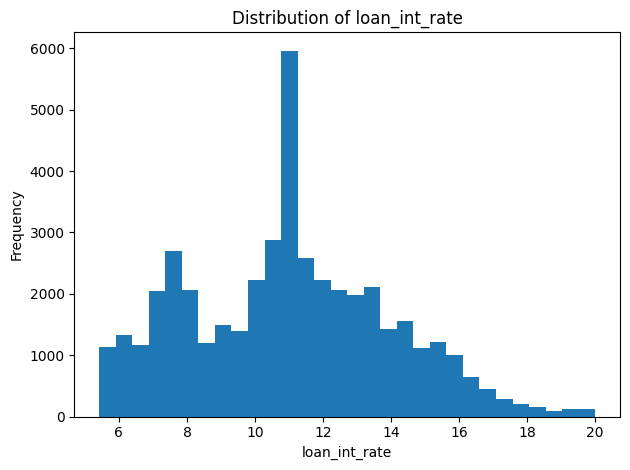

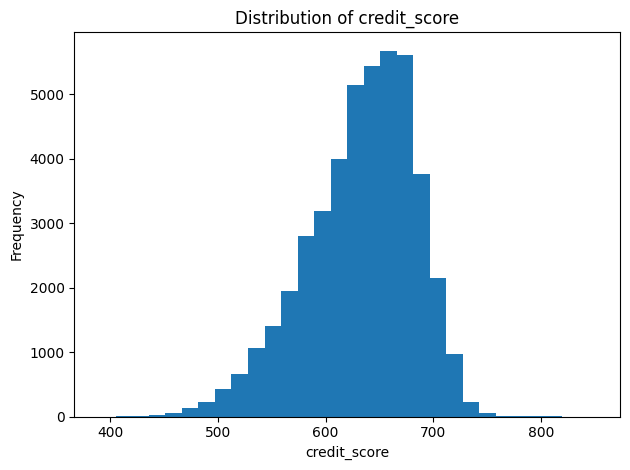

In [8]:
numerical_cols = ['person_age', 'person_income', 'loan_amnt', 'loan_int_rate', 'credit_score']

for col in numerical_cols:
    plt.figure()
    plt.hist(df[col], bins=30)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

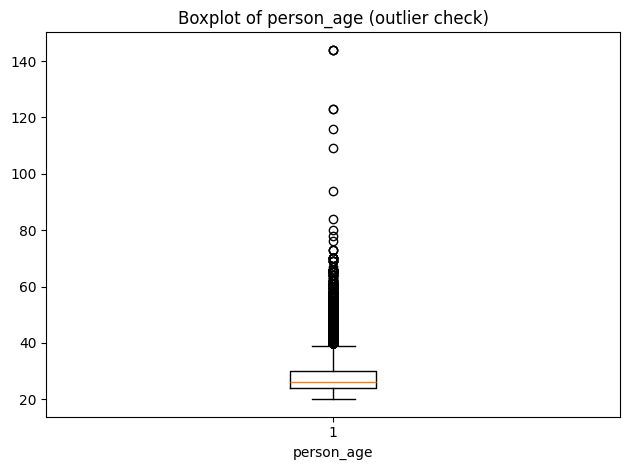

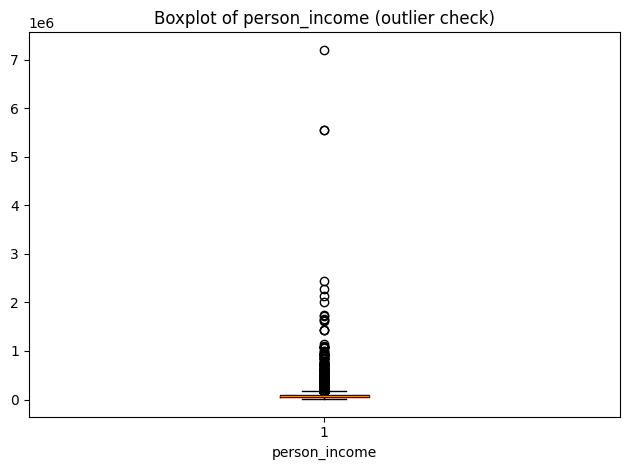

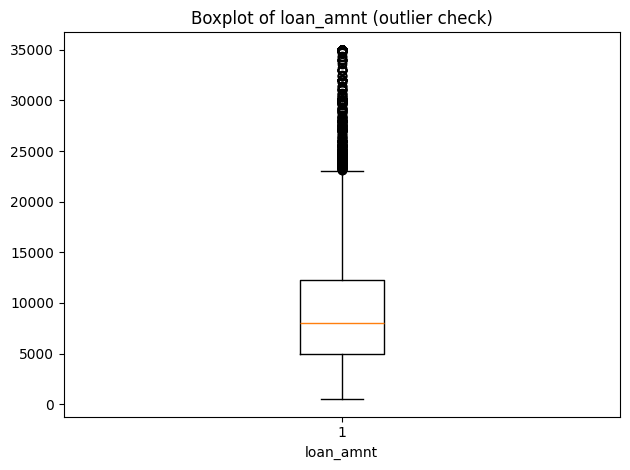

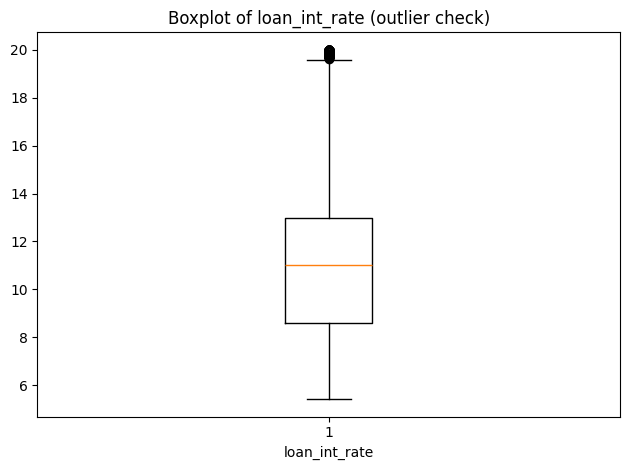

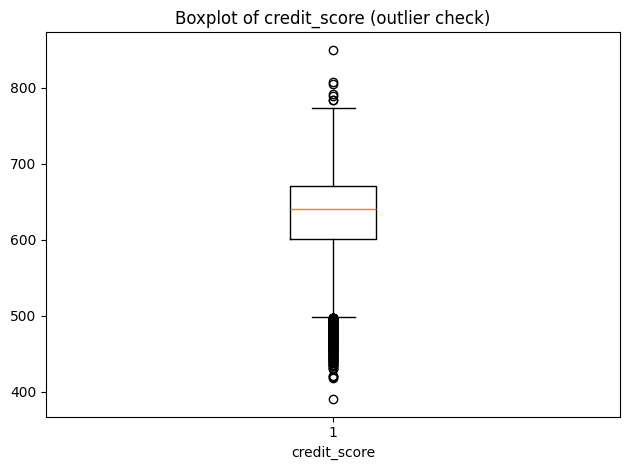

In [9]:
for col in numerical_cols:
    plt.figure()
    plt.boxplot(df[col])
    plt.xlabel(col)
    plt.title(f"Boxplot of {col} (outlier check)")
    plt.tight_layout()
    plt.show()

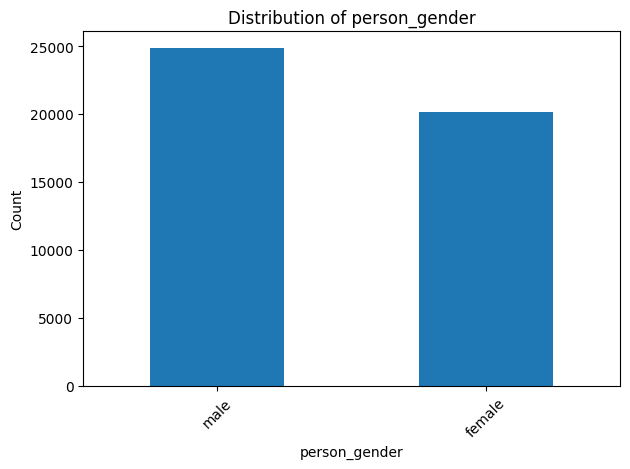

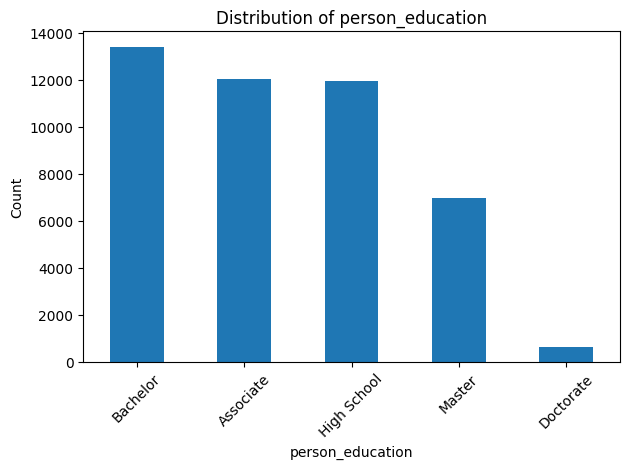

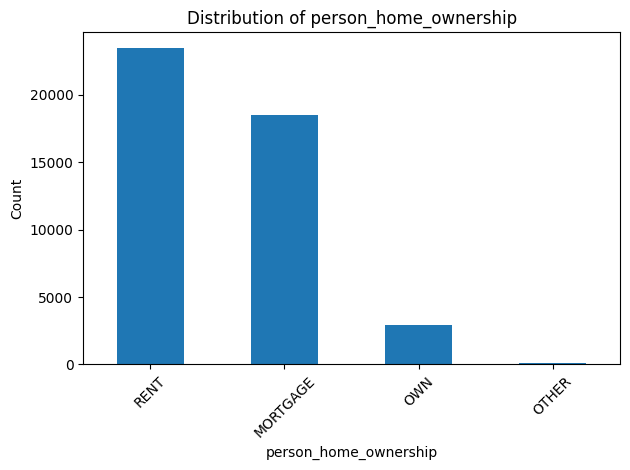

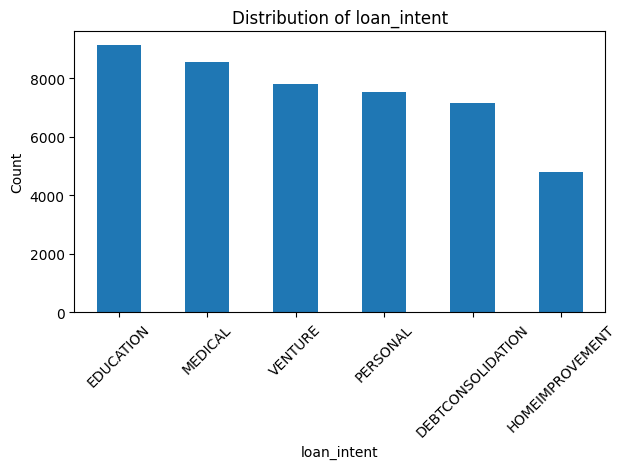

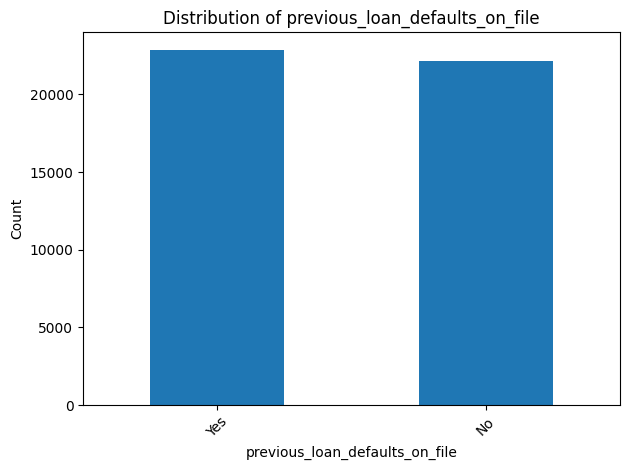

In [10]:
for col in categorical_cols:
    plt.figure()
    df[col].value_counts().plot(kind='bar')
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

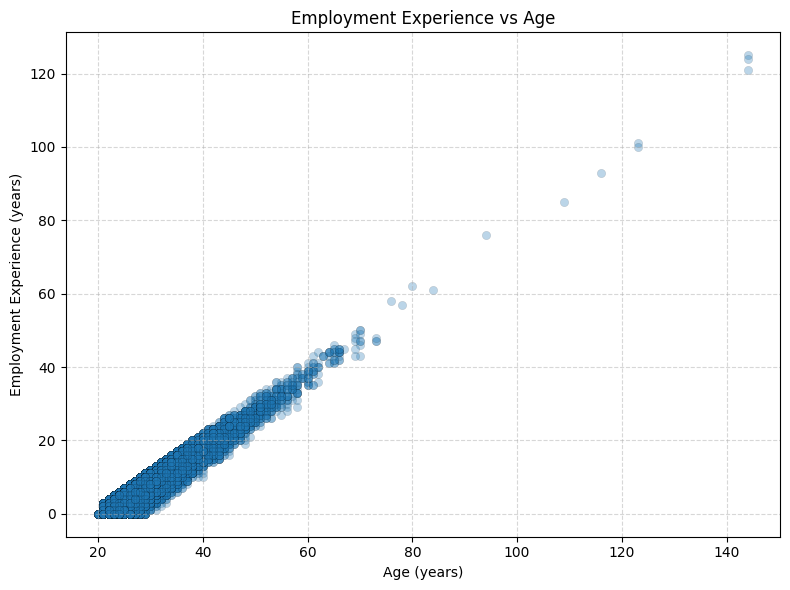

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(df["person_age"], df["person_emp_exp"], alpha=0.3, edgecolor="k", linewidth=0.2)
plt.title("Employment Experience vs Age")
plt.xlabel("Age (years)")
plt.ylabel("Employment Experience (years)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

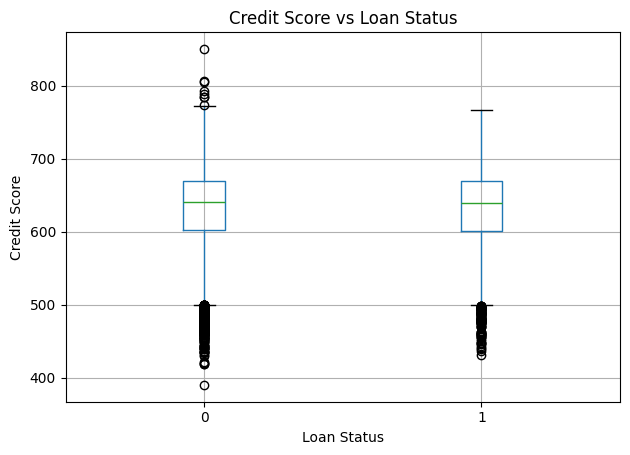

In [12]:
plt.figure()
df.boxplot(column='credit_score', by='loan_status')
plt.xlabel("Loan Status")
plt.ylabel("Credit Score")
plt.title("Credit Score vs Loan Status")
plt.suptitle("")
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

Steps: cap outliers (IQR method) on skewed numeric features, impute (median for numeric,
mode for categorical — a no-op here since there are no missing values, but kept for
robustness on unseen data), one-hot encode categoricals, and standardize numeric features.

In [13]:
outlier_cols = ['person_age', 'person_income', 'person_emp_exp']

for col in outlier_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower, upper)

print("Numeric columns after outlier capping:")
df[outlier_cols].describe()

Numeric columns after outlier capping:


,person_age,person_income,person_emp_exp
count,45000.000000,45000.000000,45000.000000
mean,27.444733,75677.400428,5.170311
std,4.930055,38071.779506,5.137068
min,20.000000,8000.000000,0.000000
25%,24.000000,47204.000000,1.000000
50%,26.000000,67048.000000,4.000000
75%,30.000000,95789.250000,8.000000
max,39.000000,168667.125000,18.500000


In [14]:
TARGET = 'loan_status'

X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].astype(int).copy()

numeric_features = [
    'person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
    'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
    'credit_score'
]
categorical_features = [
    'person_gender', 'person_education', 'person_home_ownership',
    'loan_intent', 'previous_loan_defaults_on_file'
]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']
Categorical features: ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']


In [15]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

X_processed = preprocessor.fit_transform(X)
feature_names = [c.split('__', 1)[1] for c in preprocessor.get_feature_names_out()]
X_processed_df = pd.DataFrame(X_processed, columns=feature_names)

print("Final processed shape:", X_processed_df.shape)

Final processed shape: (45000, 27)


### 3.1 Correlation Analysis

Correlation with target (loan_status):
loan_status                   1.000000
loan_percent_income           0.384880
loan_int_rate                 0.332005
loan_amnt                     0.107714
credit_score                 -0.007647
cb_person_cred_hist_length   -0.014851
person_emp_exp               -0.023626
person_age                   -0.025667
person_income                -0.249146
Name: loan_status, dtype: float64


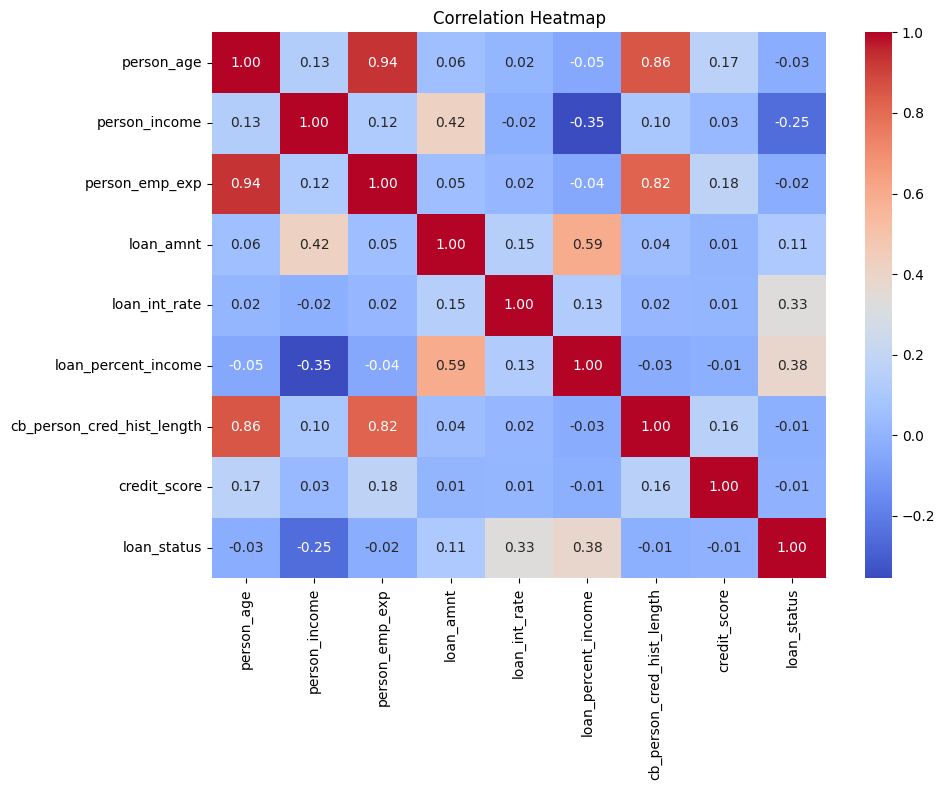

In [16]:
corr_df = df[numeric_features + [TARGET]]
corr_matrix = corr_df.corr()
print("Correlation with target (loan_status):")
print(corr_matrix[TARGET].sort_values(ascending=False))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('results/correlation_heatmap.png')
plt.show()

### 3.2 Train / Validation / Test Split (60 / 20 / 20)

In [17]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_processed_df, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=RANDOM_STATE
)  # 0.25 x 0.8 = 0.2 overall

print("Train:", X_train.shape, "Validation:", X_val.shape, "Test:", X_test.shape)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Train: (27000, 27) Validation: (9000, 27) Test: (9000, 27)


### 3.3 Feature Importance and Selection

A quick Random Forest is fit on the training set to rank features by Gini importance.
Features with negligible importance (< 0.01) are dropped from all splits to simplify the
final models without hurting performance.

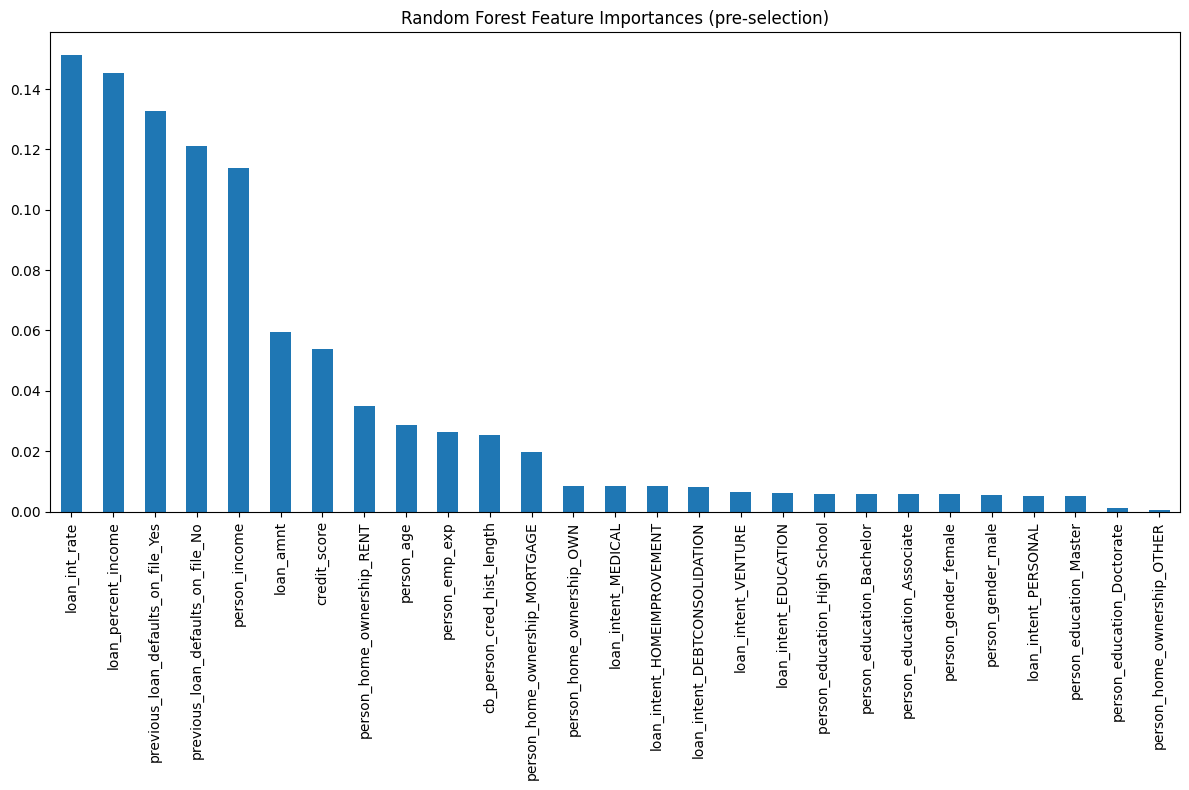

Dropping 15 low-importance features:
['person_home_ownership_OWN', 'loan_intent_MEDICAL', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_DEBTCONSOLIDATION', 'loan_intent_VENTURE', 'loan_intent_EDUCATION', 'person_education_High School', 'person_education_Bachelor', 'person_education_Associate', 'person_gender_female', 'person_gender_male', 'loan_intent_PERSONAL', 'person_education_Master', 'person_education_Doctorate', 'person_home_ownership_OTHER']
Final train shape after selection: (27000, 12)


In [18]:
rf_selector = RandomForestClassifier(random_state=RANDOM_STATE)
rf_selector.fit(X_train, y_train)

feature_imp = pd.Series(rf_selector.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
feature_imp.plot(kind='bar')
plt.title('Random Forest Feature Importances (pre-selection)')
plt.tight_layout()
plt.savefig('results/feature_importance_chart.png')
plt.show()

low_imp_features = feature_imp[feature_imp < 0.01].index.tolist()
print(f"Dropping {len(low_imp_features)} low-importance features:\n{low_imp_features}")

X_train = X_train.drop(columns=low_imp_features)
X_val = X_val.drop(columns=low_imp_features)
X_test = X_test.drop(columns=low_imp_features)

print("Final train shape after selection:", X_train.shape)

## 4. Model Training and Evaluation

### 4.1 Logistic Regression

In [19]:
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
proba_lr = lr.predict_proba(X_test)[:, 1]

print("Logistic Regression — Test Metrics")
print(classification_report(y_test, y_pred_lr, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, proba_lr))

Logistic Regression — Test Metrics
              precision    recall  f1-score   support

           0     0.9298    0.9399    0.9348      7000
           1     0.7812    0.7515    0.7661      2000

    accuracy                         0.8980      9000
   macro avg     0.8555    0.8457    0.8504      9000
weighted avg     0.8967    0.8980    0.8973      9000

ROC-AUC: 0.9527137857142858


### 4.2 Random Forest

In [20]:
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
proba_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest — Test Metrics")
print(classification_report(y_test, y_pred_rf, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, proba_rf))

final_importance = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nTop features:")
print(final_importance.head(10))

Random Forest — Test Metrics
              precision    recall  f1-score   support

           0     0.9338    0.9671    0.9502      7000
           1     0.8686    0.7600    0.8107      2000

    accuracy                         0.9211      9000
   macro avg     0.9012    0.8636    0.8804      9000
weighted avg     0.9193    0.9211    0.9192      9000

ROC-AUC: 0.9690243928571429

Top features:
loan_int_rate                         0.168906
loan_percent_income                   0.164884
previous_loan_defaults_on_file_No     0.133585
person_income                         0.125584
previous_loan_defaults_on_file_Yes    0.122111
credit_score                          0.068326
loan_amnt                             0.063255
person_home_ownership_RENT            0.045807
person_age                            0.032410
person_emp_exp                        0.030600
dtype: float64


### 4.3 Neural Network (PyTorch)

A small feedforward network: two hidden layers with ReLU activations and dropout for
regularization, trained with binary cross-entropy loss and the Adam optimizer.

In [21]:
X_train_t = torch.tensor(X_train.values, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_val_t = torch.tensor(X_val.values, dtype=torch.float32)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test.values, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=64)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64)


class FFN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FFN(X_train.shape[1]).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 20
train_losses, val_losses = [], []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = model(xb)
        loss = criterion(preds, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    epoch_loss /= len(train_loader.dataset)
    train_losses.append(epoch_loss)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            val_loss += criterion(model(xb), yb).item() * xb.size(0)
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{epochs} — train_loss: {epoch_loss:.4f} — val_loss: {val_loss:.4f}")

Epoch 1/20 — train_loss: 0.2796 — val_loss: 0.2277


Epoch 2/20 — train_loss: 0.2241 — val_loss: 0.2143


Epoch 3/20 — train_loss: 0.2144 — val_loss: 0.2102


Epoch 4/20 — train_loss: 0.2093 — val_loss: 0.2080


Epoch 5/20 — train_loss: 0.2052 — val_loss: 0.2083


...

Epoch 16/20 — train_loss: 0.1934 — val_loss: 0.1954


Epoch 17/20 — train_loss: 0.1925 — val_loss: 0.1954


Epoch 18/20 — train_loss: 0.1915 — val_loss: 0.1951


Epoch 19/20 — train_loss: 0.1910 — val_loss: 0.1939


Epoch 20/20 — train_loss: 0.1915 — val_loss: 0.1943


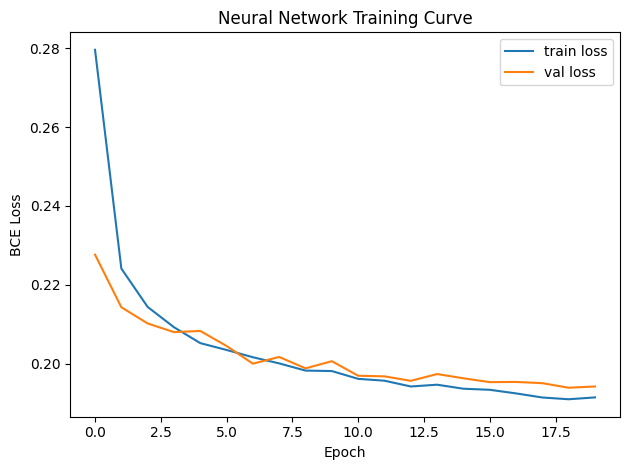

In [22]:
plt.figure()
plt.plot(train_losses, label='train loss')
plt.plot(val_losses, label='val loss')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('Neural Network Training Curve')
plt.legend()
plt.tight_layout()
plt.savefig('results/nn_training_curve.png')
plt.show()

In [23]:
model.eval()
all_proba, all_targets = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        proba = model(xb).cpu().numpy()
        all_proba.append(proba)
        all_targets.append(yb.numpy())

proba_nn = np.vstack(all_proba).ravel()
y_test_nn = np.vstack(all_targets).ravel()
y_pred_nn = (proba_nn >= 0.5).astype(int)

print("Neural Network — Test Metrics")
print(classification_report(y_test_nn, y_pred_nn, digits=4))
print("ROC-AUC:", roc_auc_score(y_test_nn, proba_nn))

Neural Network — Test Metrics
              precision    recall  f1-score   support

         0.0     0.9312    0.9623    0.9465      7000
         1.0     0.8505    0.7510    0.7977      2000

    accuracy                         0.9153      9000
   macro avg     0.8908    0.8566    0.8721      9000
weighted avg     0.9132    0.9153    0.9134      9000

ROC-AUC: 0.965588642857143


### 4.4 XGBoost

A gradient-boosted tree model, added to test whether boosting improves on Random Forest's
bagged trees for this tabular dataset — the comparison discussed only hypothetically in the
project report is trained here for real.

In [24]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("XGBoost — Test Metrics")
print(classification_report(y_test, y_pred_xgb, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, proba_xgb))

xgb_importance = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nTop features:")
print(xgb_importance.head(10))

XGBoost — Test Metrics
              precision    recall  f1-score   support

           0     0.9400    0.9661    0.9529      7000
           1     0.8687    0.7840    0.8242      2000

    accuracy                         0.9257      9000
   macro avg     0.9043    0.8751    0.8885      9000
weighted avg     0.9241    0.9257    0.9243      9000

ROC-AUC: 0.9734020714285714

Top features:
previous_loan_defaults_on_file_No     0.568665
previous_loan_defaults_on_file_Yes    0.334430
person_home_ownership_RENT            0.026565
loan_percent_income                   0.020404
person_home_ownership_MORTGAGE        0.013949
loan_int_rate                         0.012464
person_income                         0.008006
credit_score                          0.004174
loan_amnt                             0.003860
person_age                            0.002575
dtype: float32


## 5. Model Comparison

In [25]:
results_df = pd.DataFrame([
    {
        'model': 'Logistic Regression',
        'accuracy': accuracy_score(y_test, y_pred_lr),
        'precision': precision_score(y_test, y_pred_lr),
        'recall': recall_score(y_test, y_pred_lr),
        'f1': f1_score(y_test, y_pred_lr),
        'roc_auc': roc_auc_score(y_test, proba_lr),
    },
    {
        'model': 'Random Forest',
        'accuracy': accuracy_score(y_test, y_pred_rf),
        'precision': precision_score(y_test, y_pred_rf),
        'recall': recall_score(y_test, y_pred_rf),
        'f1': f1_score(y_test, y_pred_rf),
        'roc_auc': roc_auc_score(y_test, proba_rf),
    },
    {
        'model': 'Neural Network',
        'accuracy': accuracy_score(y_test_nn, y_pred_nn),
        'precision': precision_score(y_test_nn, y_pred_nn),
        'recall': recall_score(y_test_nn, y_pred_nn),
        'f1': f1_score(y_test_nn, y_pred_nn),
        'roc_auc': roc_auc_score(y_test_nn, proba_nn),
    },
    {
        'model': 'XGBoost',
        'accuracy': accuracy_score(y_test, y_pred_xgb),
        'precision': precision_score(y_test, y_pred_xgb),
        'recall': recall_score(y_test, y_pred_xgb),
        'f1': f1_score(y_test, y_pred_xgb),
        'roc_auc': roc_auc_score(y_test, proba_xgb),
    },
])

results_df.to_csv('results/model_comparison.csv', index=False)
results_df

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.898000,0.781185,0.7515,0.766055,0.952714
1,Random Forest,0.921111,0.868571,0.7600,0.810667,0.969024
2,Neural Network,0.915333,0.850510,0.7510,0.797663,0.965589
3,XGBoost,0.925667,0.868698,0.7840,0.824179,0.973402


## 6. Save Models

In [26]:
os.makedirs("models", exist_ok=True)

joblib.dump(lr, "models/logistic_regression.joblib")
joblib.dump(rf, "models/random_forest.joblib")
joblib.dump(xgb, "models/xgboost.joblib")
torch.save(model.state_dict(), "models/nn_model.pth")
joblib.dump(preprocessor, "models/preprocessor.joblib")

print("Models saved to 'models/'")

Models saved to 'models/'
